In [6]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from scipy.optimize import minimize_scalar, root
# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

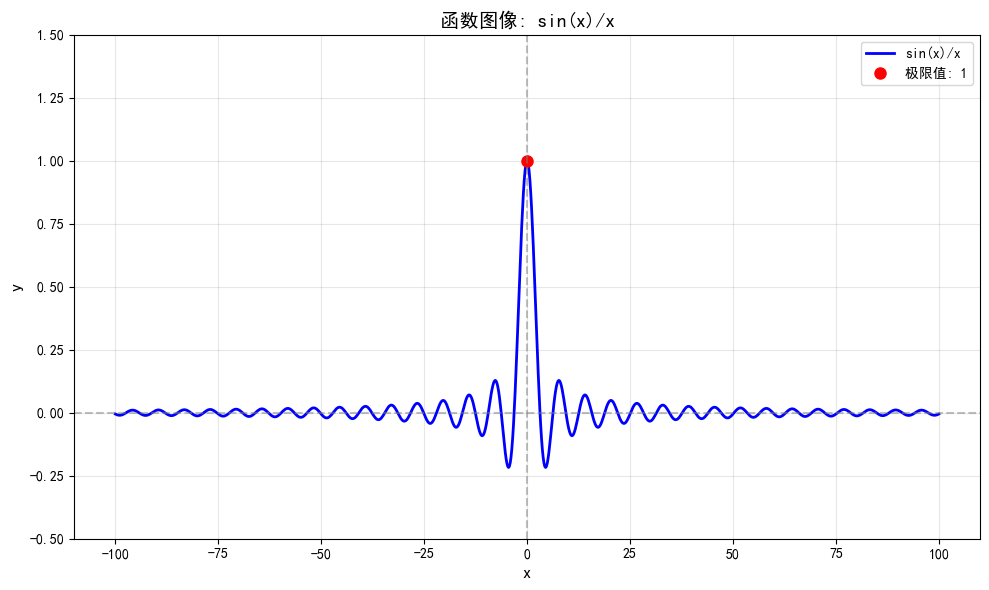

In [7]:

# 方法1：使用 sinc 函数（numpy 的 sinc 定义为 sin(πx)/(πx)）
x = np.linspace(-100, 100, 1000)
y = np.sinc(x / np.pi)  # 转换为 sin(x)/x

# 创建图像
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x, y, 'b-', linewidth=2, label='sin(x)/x')
ax.plot(0, 1, 'ro', markersize=8, label='极限值: 1')

# 美化图像
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3)
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('y', fontsize=12)
ax.set_title('函数图像: sin(x)/x', fontsize=14)
ax.legend()
ax.set_ylim(-0.5, 1.5)

plt.tight_layout()
plt.show()

In [3]:
# 定义符号变量
x = sp.symbols('x')

# 定义函数 f(x) = e^(2x) * sin(x)
f = sp.exp(2*x) * sp.sin(x)

# 计算导数
f_prime = sp.diff(f, x)

print(f"f(x) = {f}")
print(f"f'(x) = {f_prime}")
print(f"f'(x) 化简 = {sp.simplify(f_prime)}")

# 在指定点计算导数值
x0 = 0  # 可以修改为你想要的点
value = f_prime.subs(x, x0)
print(f"f'({x0}) = {value}")
print(f"f'({x0}) ≈ {float(value):.6f}")

f(x) = exp(2*x)*sin(x)
f'(x) = 2*exp(2*x)*sin(x) + exp(2*x)*cos(x)
f'(x) 化简 = (2*sin(x) + cos(x))*exp(2*x)
f'(0) = 1
f'(0) ≈ 1.000000


In [5]:
x, y = sp.symbols('x y')

# 定义隐函数方程: ln(sqrt(x^2 + y^2)) - atan(y/x) = 0
# 等价于: (1/2)*ln(x^2 + y^2) - atan(y/x) = 0
F = sp.ln(sp.sqrt(x**2 + y**2)) - sp.atan(y/x)

# 隐函数求导公式: dy/dx = -F_x / F_y
F_x = sp.diff(F, x)  # 对 x 求偏导
F_y = sp.diff(F, y)  # 对 y 求偏导

dy_dx = -F_x / F_y

print(f"F(x, y) = ln(√(x² + y²)) - arctan(y/x) = {F}")
print(f"\n∂F/∂x = {sp.simplify(F_x)}")
print(f"\n∂F/∂y = {sp.simplify(F_y)}")
print(f"\ndy/dx = -∂F/∂x / ∂F/∂y")
print(f"      = {sp.simplify(dy_dx)}")

F(x, y) = ln(√(x² + y²)) - arctan(y/x) = log(sqrt(x**2 + y**2)) - atan(y/x)

∂F/∂x = (x + y)/(x**2 + y**2)

∂F/∂y = (-x + y)/(x**2 + y**2)

dy/dx = -∂F/∂x / ∂F/∂y
      = (x + y)/(x - y)


In [6]:
x, y = sp.symbols('x y')

# 定义隐函数方程: ln(sqrt(x^2 + y^2)) - atan(y/x) = 0
F = sp.ln(sp.sqrt(x**2 + y**2)) - sp.atan(y/x)

# 使用 idiff 直接求 dy/dx
# idiff(方程, 因变量, 自变量)
dy_dx = sp.idiff(F, y, x)

print(f"方程: ln(√(x² + y²)) = arctan(y/x)")
print(f"\ndy/dx = {dy_dx}")
print(f"\n化简后:\n{dy_dx.simplify()}")

方程: ln(√(x² + y²)) = arctan(y/x)

dy/dx = (x + y)/(x - y)

化简后:
(x + y)/(x - y)


In [7]:
n = sp.symbols('n', integer=True, positive=True)

# 方法1：直接用 summation 计算无穷级数
print("\n方法1: 直接计算无穷级数")
result = sp.summation(1/n**2, (n, 1, sp.oo))
print(f"∑(1/n²) = {result}")
print(f"数值近似: {result.evalf()}")


方法1: 直接计算无穷级数
∑(1/n²) = pi**2/6
数值近似: 1.64493406684823


In [8]:
n = sp.symbols('n', integer=True, positive=True)
x = sp.symbols('x')

# 定义级数的通项 a_n = 1/n
a_n = 1 / n

# ========== 方法1：比值法求收敛半径 ==========
print("\n方法1: 比值法 (Ratio Test)")
a_n_plus_1 = 1 / (n + 1)
ratio = sp.simplify(sp.Abs(a_n_plus_1 / a_n))
print(f"a_(n+1)/a_n = {ratio}")
limit_ratio = sp.limit(ratio, n, sp.oo)
print(f"lim |a_(n+1)/a_n| = {limit_ratio}")
R = 1 / limit_ratio
print(f"收敛半径 R = 1/lim = {R}")


方法1: 比值法 (Ratio Test)
a_(n+1)/a_n = n/(n + 1)
lim |a_(n+1)/a_n| = 1
收敛半径 R = 1/lim = 1


In [10]:
print("\n" + "=" * 60)
print("端点收敛性分析")
print("=" * 60)

# 端点 x = 1：级数为 ∑(1/n)，调和级数
print("\n端点 x = 1: 级数为 ∑(1/n)")
print("这是调和级数，发散")
# 用 SymPy 验证
series_x1 = sp.summation(1/n, (n, 1, sp.oo))
print(f"∑(1/n) = {series_x1}")

# 端点 x = -1：级数为 ∑((-1)^n / n)，交错级数
print("\n端点 x = -1: 级数为 ∑((-1)^n / n)")
print("这是交错调和级数，由莱布尼茨判别法，收敛（条件收敛）")
# 用 SymPy 验证（这个级数收敛到 -ln(2)）
series_x_neg1 = sp.summation((-1)**n / n, (n, 1, sp.oo))
print(f"∑((-1)^n / n) = {series_x_neg1}")
print(f"数值: {series_x_neg1.evalf()}")
print(f"验证 -ln(2) = {-sp.log(2).evalf()}")


端点收敛性分析

端点 x = 1: 级数为 ∑(1/n)
这是调和级数，发散
∑(1/n) = oo

端点 x = -1: 级数为 ∑((-1)^n / n)
这是交错调和级数，由莱布尼茨判别法，收敛（条件收敛）
∑((-1)^n / n) = -log(2)
数值: -0.693147180559945
验证 -ln(2) = -0.693147180559945


In [11]:
print("=" * 60)
print("(1+x)^(1/5) 在 x=1 处的 3 阶泰勒展开")
print("=" * 60)

x = sp.symbols('x')

# 定义函数 f(x) = (1+x)^(1/5)
f = (1 + x) ** (sp.Rational(1, 5))

# 方法1：用 sp.series() 在 x=1 处展开到 3 阶
print("\n方法1: 使用 sp.series()")
taylor_series = sp.series(f, x, 1, 4)  # 展开到 (x-1)^3 项，需要写到 4
print(f"f(x) = {taylor_series}")

# 去掉 O((x-1)^4) 项，得到多项式
taylor_poly = sp.series(f, x, 1, 4).removeO()
print(f"\n泰勒多项式（3阶）:\n{taylor_poly}")

(1+x)^(1/5) 在 x=1 处的 3 阶泰勒展开

方法1: 使用 sp.series()
f(x) = 2**(1/5) + 2**(1/5)*(x - 1)/10 - 2**(1/5)*(x - 1)**2/50 + 3*2**(1/5)*(x - 1)**3/500 + O((x - 1)**4, (x, 1))

泰勒多项式（3阶）:
3*2**(1/5)*(x - 1)**3/500 - 2**(1/5)*(x - 1)**2/50 + 2**(1/5)*(x - 1)/10 + 2**(1/5)


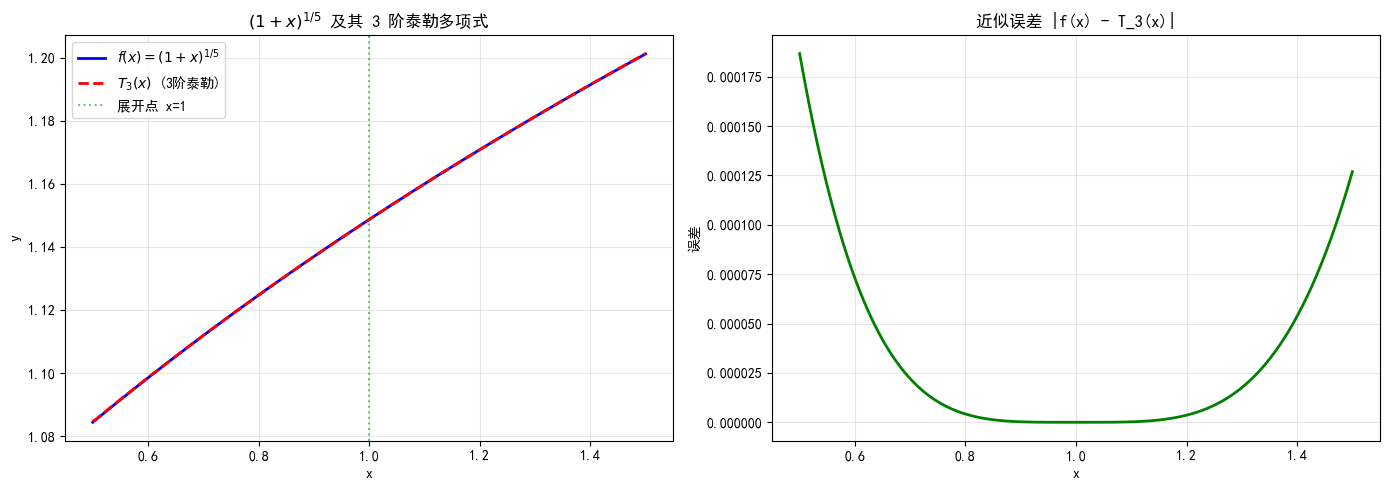

In [16]:
# 定义函数和泰勒多项式（数值形式）
def f_func(x_val):
    return (1 + x_val) ** 0.2  # 1/5 = 0.2

# 将 SymPy 表达式转换为可计算的函数
T3_func = sp.lambdify(x, taylor_poly, 'numpy')

x_vals = np.linspace(0.5, 1.5, 1000)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 子图1：函数和泰勒多项式
ax1.plot(x_vals, f_func(x_vals), 'b-', linewidth=2, label='$f(x) = (1+x)^{1/5}$')
ax1.plot(x_vals, T3_func(x_vals), 'r--', linewidth=2, label='$T_3(x)$ (3阶泰勒)')
ax1.axvline(x=1, color='g', linestyle=':', alpha=0.5, label='展开点 x=1')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title('$(1+x)^{1/5}$ 及其 3 阶泰勒多项式')
ax1.grid(True, alpha=0.3)
ax1.legend()

# 子图2：误差
error = np.abs(f_func(x_vals) - T3_func(x_vals))
ax2.plot(x_vals, error, 'g-', linewidth=2)
ax2.set_xlabel('x')
ax2.set_ylabel('误差')
ax2.set_title('近似误差 |f(x) - T_3(x)|')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
print("=" * 60)
print("f(x,y) = e^(xy) * sin(x+y) 的偏导数")
print("=" * 60)

x, y = sp.symbols('x y')

# 定义函数
f = sp.exp(x * y) * sp.sin(x + y)
print(f"f(x, y) = {f}")

# ========== 一阶偏导数 ==========
print("\n" + "=" * 60)
print("一阶偏导数")
print("=" * 60)

# ∂f/∂x
f_x = sp.diff(f, x)
print(f"\n∂f/∂x = {sp.simplify(f_x)}")

# ∂f/∂y
f_y = sp.diff(f, y)
print(f"\n∂f/∂y = {sp.simplify(f_y)}")

f(x,y) = e^(xy) * sin(x+y) 的偏导数
f(x, y) = exp(x*y)*sin(x + y)

一阶偏导数

∂f/∂x = (y*sin(x + y) + cos(x + y))*exp(x*y)

∂f/∂y = (x*sin(x + y) + cos(x + y))*exp(x*y)


In [19]:
print("=" * 60)
print("f(x,y) = x²y - xy 的梯度")
print("=" * 60)

x, y = sp.symbols('x y')

# 定义函数
f = x**2 * y - x * y
print(f"f(x, y) = {f}")

# ========== 计算梯度 ==========
print("\n" + "=" * 60)
print("梯度 ∇f = (∂f/∂x, ∂f/∂y)")
print("=" * 60)

# ∂f/∂x
f_x = sp.diff(f, x)
print(f"\n∂f/∂x = {f_x}")

# ∂f/∂y
f_y = sp.diff(f, y)
print(f"\n∂f/∂y = {f_y}")

# 梯度向量
gradient = sp.Matrix([f_x, f_y])
print(f"\n∇f = {gradient}")

f(x,y) = x²y - xy 的梯度
f(x, y) = x**2*y - x*y

梯度 ∇f = (∂f/∂x, ∂f/∂y)

∂f/∂x = 2*x*y - y

∂f/∂y = x**2 - x

∇f = Matrix([[2*x*y - y], [x**2 - x]])



梯度为零的点（驻点）
驻点: [(0, 0), (1, 0)]


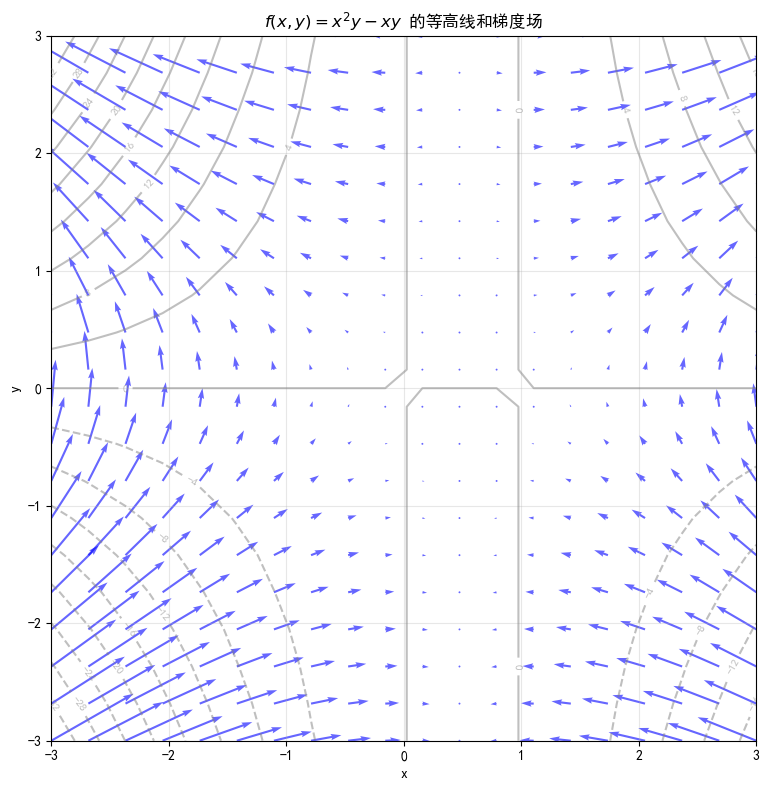

In [20]:
# 创建网格
x_grid = np.linspace(-3, 3, 20)
y_grid = np.linspace(-3, 3, 20)
X, Y = np.meshgrid(x_grid, y_grid)

# 计算函数值
F = X**2 * Y - X * Y

# 计算梯度（数值）
F_x = 2 * X * Y - Y  # ∂f/∂x
F_y = X**2 - X       # ∂f/∂y

# 绘制
fig, ax = plt.subplots(figsize=(10, 8))

# 等高线
contours = ax.contour(X, Y, F, levels=20, colors='gray', alpha=0.5)
ax.clabel(contours, inline=True, fontsize=8)

# 梯度场（箭头）
ax.quiver(X, Y, F_x, F_y, color='blue', alpha=0.6, 
          angles='xy', scale_units='xy', scale=30, width=0.003)

# 标记一些特殊点
# 梯度为零的点（驻点）
print("\n" + "=" * 60)
print("梯度为零的点（驻点）")
print("=" * 60)
# 解 ∂f/∂x = 0 和 ∂f/∂y = 0
solutions = sp.solve([f_x, f_y], [x, y])
print(f"驻点: {solutions}")

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('$f(x,y) = x^2y - xy$ 的等高线和梯度场')
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

绘制 z = x²y - xy 的 3D 曲面


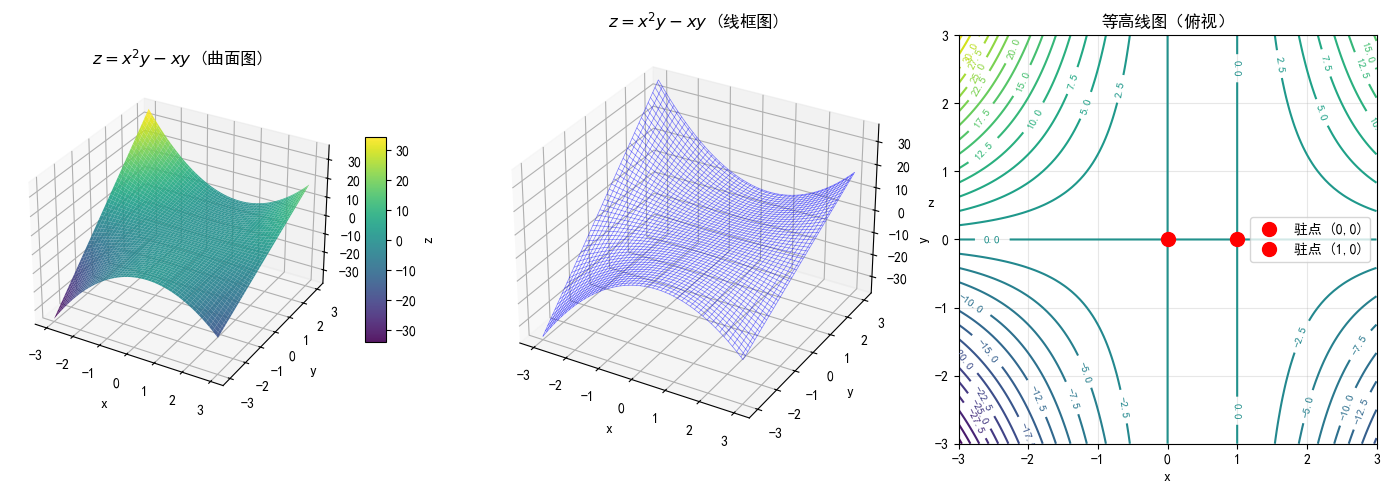


正在绘制梯度场...


D:\ProgramFiles\anaconda3\envs\HoML\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


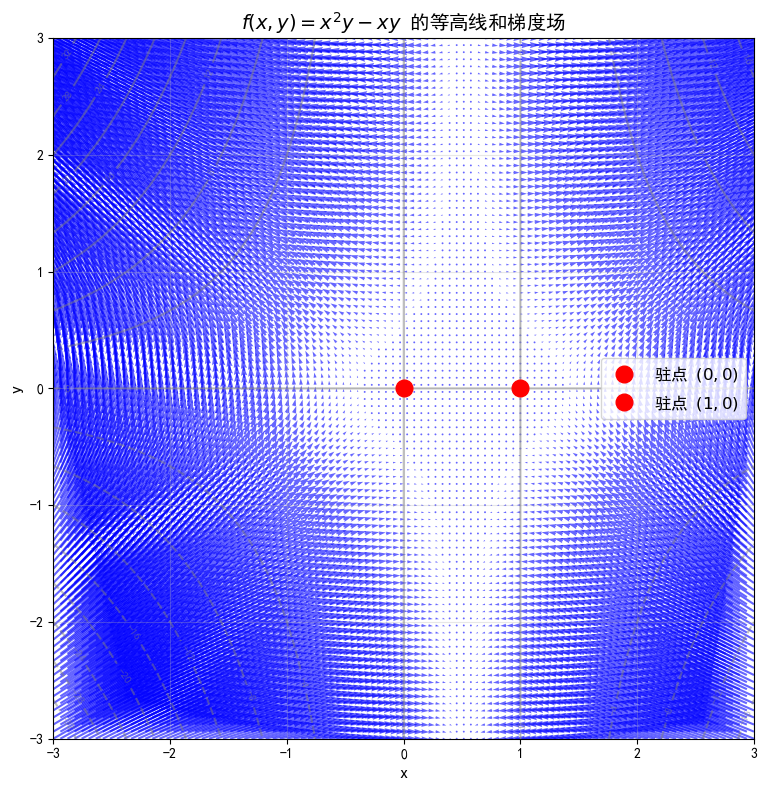


函数特性分析

函数: f(x,y) = x²y - xy

梯度:
  ∂f/∂x = 2*x*y - y
  ∂f/∂y = x**2 - x

Hessian 矩阵:
  ∂²f/∂x² = 2*y
  ∂²f/∂y² = 0
  ∂²f/∂x∂y = 2*x - 1

在驻点 (0,0) 的 Hessian:
  H = Matrix([[0, -1], [-1, 0]])
  行列式 = -1


In [21]:
# ========== 绘制 z = x²y - xy 的 3D 图像 ==========
print("=" * 60)
print("绘制 z = x²y - xy 的 3D 曲面")
print("=" * 60)

# 创建网格
x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x, y)

# 计算 z
Z = X**2 * Y - X * Y

# ========== 图1：3D 曲面图 ==========
fig = plt.figure(figsize=(14, 5))

# 子图1：3D 曲面
ax1 = fig.add_subplot(131, projection='3d')
surf = ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.9, 
                        antialiased=True, edgecolor='none')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('z')
ax1.set_title('$z = x^2y - xy$ (曲面图)')

# 添加颜色条
fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=10, label='z')

# ========== 图2：线框图（更清晰看结构）==========
ax2 = fig.add_subplot(132, projection='3d')
# 用更粗的线框
ax2.plot_wireframe(X, Y, Z, color='blue', alpha=0.5, linewidth=0.5)
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_zlabel('z')
ax2.set_title('$z = x^2y - xy$ (线框图)')

# ========== 图3：等高线图（从上方看）==========
ax3 = fig.add_subplot(133)
contour = ax3.contour(X, Y, Z, levels=30, cmap='viridis')
ax3.clabel(contour, inline=True, fontsize=8)
# 标记驻点
ax3.plot(0, 0, 'ro', markersize=10, label='驻点 (0,0)')
ax3.plot(1, 0, 'ro', markersize=10, label='驻点 (1,0)')
ax3.set_xlabel('x')
ax3.set_ylabel('y')
ax3.set_title('等高线图（俯视）')
ax3.grid(True, alpha=0.3)
ax3.legend()

plt.tight_layout()
plt.show()

# ========== 额外：绘制梯度场在 xy 平面的投影 ==========
print("\n正在绘制梯度场...")

fig2, ax = plt.subplots(figsize=(10, 8))

# 计算梯度
F_x = 2 * X * Y - Y  # ∂f/∂x
F_y = X**2 - X       # ∂f/∂y

# 梯度场箭头
ax.quiver(X, Y, F_x, F_y, color='blue', alpha=0.6,
          angles='xy', scale_units='xy', scale=30, width=0.003)

# 等高线
contour = ax.contour(X, Y, Z, levels=20, colors='gray', alpha=0.5)
ax.clabel(contour, inline=True, fontsize=8)

# 标记驻点（梯度为零）
ax.plot(0, 0, 'ro', markersize=12, label='驻点 $(0,0)$')
ax.plot(1, 0, 'ro', markersize=12, label='驻点 $(1,0)$')

ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('y', fontsize=12)
ax.set_title('$f(x,y) = x^2y - xy$ 的等高线和梯度场', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=12)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

# ========== 分析函数的特性 ==========
print("\n" + "=" * 60)
print("函数特性分析")
print("=" * 60)

import sympy as sp
x_sym, y_sym = sp.symbols('x y')
f_sym = x_sym**2 * y_sym - x_sym * y_sym

# 梯度
f_x = sp.diff(f_sym, x_sym)
f_y = sp.diff(f_sym, y_sym)

# Hessian 矩阵
H_xx = sp.diff(f_sym, x_sym, 2)
H_yy = sp.diff(f_sym, y_sym, 2)
H_xy = sp.diff(f_sym, x_sym, y_sym)

print(f"\n函数: f(x,y) = x²y - xy")
print(f"\n梯度:")
print(f"  ∂f/∂x = {f_x}")
print(f"  ∂f/∂y = {f_y}")

print(f"\nHessian 矩阵:")
print(f"  ∂²f/∂x² = {H_xx}")
print(f"  ∂²f/∂y² = {H_yy}")
print(f"  ∂²f/∂x∂y = {H_xy}")

# 在驻点计算 Hessian
print(f"\n在驻点 (0,0) 的 Hessian:")
H = sp.Matrix([[H_xx, H_xy], [H_xy, H_yy]])
H_at_00 = H.subs({x_sym: 0, y_sym: 0})
print(f"  H = {H_at_00}")
print(f"  行列式 = {H_at_00.det()}")


正在绘制梯度场...


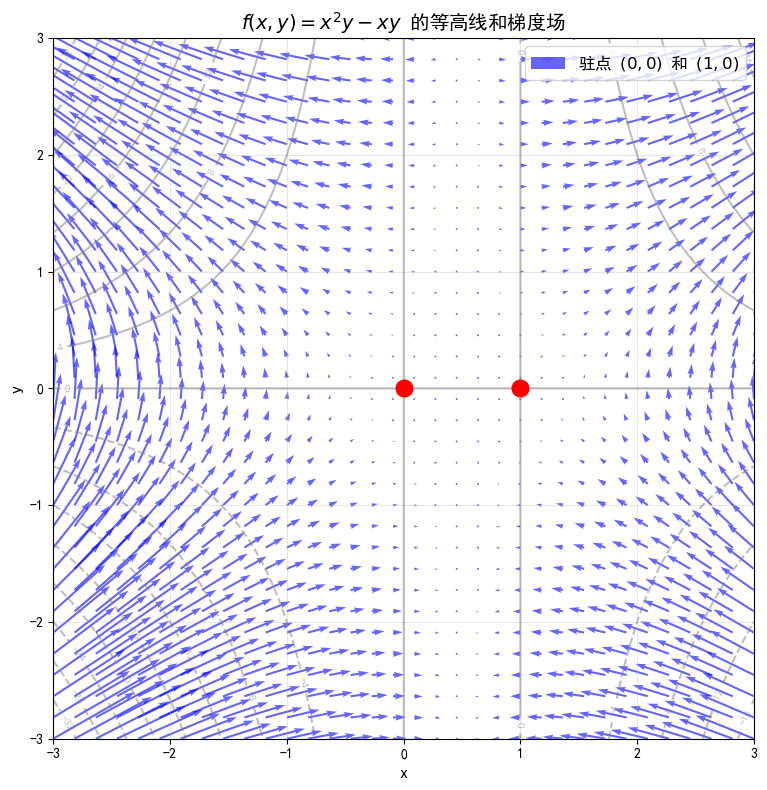

In [22]:
# ========== 梯度场（修复警告）==========
print("\n正在绘制梯度场...")

fig2, ax = plt.subplots(figsize=(10, 8))

# 计算梯度
F_x = 2 * X * Y - Y
F_y = X**2 - X

# 梯度场箭头（减少箭头数量以提高性能）
step = 3  # 每隔3个点画一个箭头
ax.quiver(X[::step, ::step], Y[::step, ::step], 
          F_x[::step, ::step], F_y[::step, ::step], 
          color='blue', alpha=0.6, angles='xy', 
          scale_units='xy', scale=30, width=0.003)

# 等高线
contour = ax.contour(X, Y, Z, levels=20, colors='gray', alpha=0.5)
ax.clabel(contour, inline=True, fontsize=8)

# 标记驻点
ax.plot(0, 0, 'ro', markersize=12)
ax.plot(1, 0, 'ro', markersize=12)

ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('y', fontsize=12)
ax.set_title('$f(x,y) = x^2y - xy$ 的等高线和梯度场', fontsize=14)
ax.grid(True, alpha=0.3)
# 修复：指定图例位置，不用 "best"
ax.legend(['驻点 $(0,0)$ 和 $(1,0)$'], loc='upper right', fontsize=12)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

f(x) = x^4 - 6x^3 + 9x - 2 的单调性分析
f(x) = x**4 - 6*x**3 + 9*x - 2

计算导数
f'(x) = 4*x**3 - 18*x**2 + 9

求驻点（f'(x) = 0）
驻点（数值）:
  x = -0.660318
  x = 0.777447
  x = 4.382871

单调性分析
f'(x) = 4*x**3 - 18*x**2 + 9

各区间导数符号:
  (-∞, -0.6603): f'(x) 负（-）, 单调递减 ↓
  (-0.6603, 0.7774): f'(x) 正（+）, 单调递增 ↑
  (0.7774, 4.3829): f'(x) 负（-）, 单调递减 ↓
  (4.3829, +∞): f'(x) 正（+）, 单调递增 ↑

正在绘制图像...


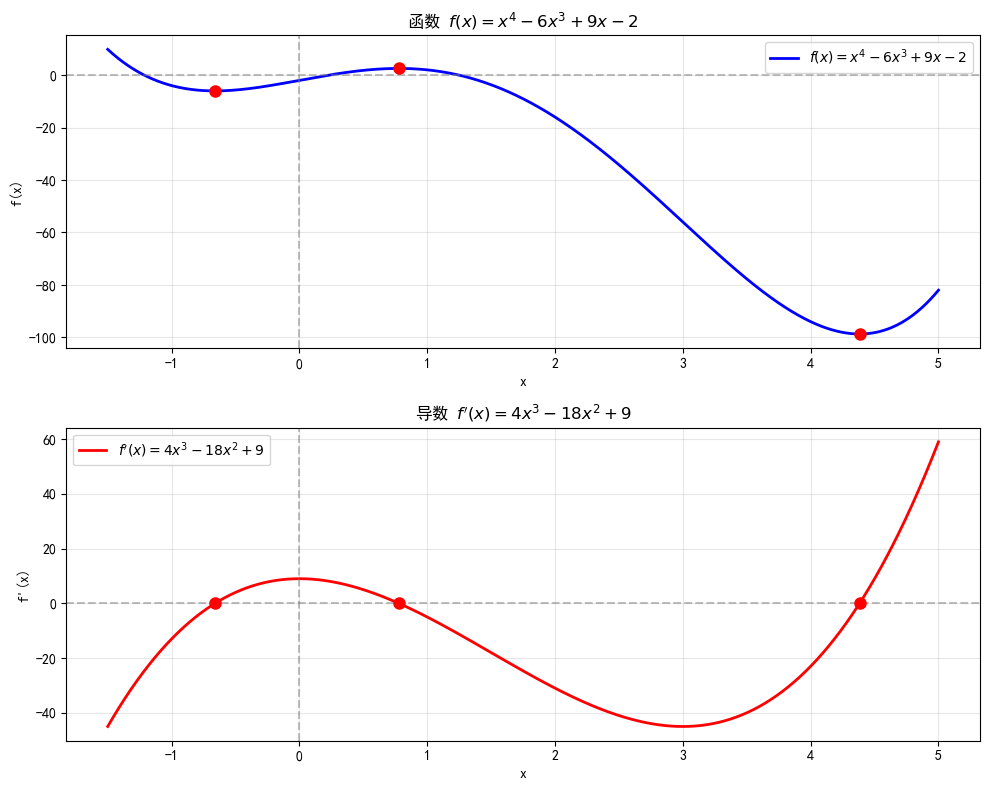


单调性总结
f(x) = x^4 - 6x^3 + 9x - 2
f'(x) = 4x^3 - 18x^2 + 9

驻点: x = -0.6603, 0.7774, 4.3829


In [25]:
# ========== f(x) = x^4 - 6x^3 + 9x - 2 的单调性分析 ==========
print("=" * 60)
print("f(x) = x^4 - 6x^3 + 9x - 2 的单调性分析")
print("=" * 60)

x = sp.symbols('x')

# 定义函数
f = x**4 - 6*x**3 + 9*x - 2
print(f"f(x) = {f}")

# ========== 计算导数 ==========
print("\n" + "=" * 60)
print("计算导数")
print("=" * 60)

f_prime = sp.diff(f, x)
print(f"f'(x) = {f_prime}")

# ========== 求驻点（f'(x) = 0）==========
print("\n" + "=" * 60)
print("求驻点（f'(x) = 0）")
print("=" * 60)

# 方法1：用 nroots 直接求数值根（避免复数表达式问题）
critical_points_sym = sp.nroots(f_prime)
critical_points = [float(cp) for cp in critical_points_sym if abs(cp.as_real_imag()[1]) < 1e-10]
critical_points.sort()

print(f"驻点（数值）:")
for cp in critical_points:
    print(f"  x = {cp:.6f}")

# ========== 分析单调性 ==========
print("\n" + "=" * 60)
print("单调性分析")
print("=" * 60)

# 因式分解（尝试）
f_prime_factor = sp.factor(f_prime)
print(f"f'(x) = {f_prime}")

# 在各区间测试导数的符号
print("\n各区间导数符号:")
# 区间划分
test_intervals = []
if len(critical_points) > 0:
    test_intervals.append((-np.inf, critical_points[0]))
    for i in range(len(critical_points) - 1):
        test_intervals.append((critical_points[i], critical_points[i+1]))
    test_intervals.append((critical_points[-1], np.inf))

f_prime_func = sp.lambdify(x, f_prime, 'numpy')

for interval in test_intervals:
    left, right = interval
    if left == -np.inf:
        test_point = critical_points[0] - 1
        interval_str = f"(-∞, {critical_points[0]:.4f})"
    elif right == np.inf:
        test_point = critical_points[-1] + 1
        interval_str = f"({critical_points[-1]:.4f}, +∞)"
    else:
        test_point = (left + right) / 2
        interval_str = f"({left:.4f}, {right:.4f})"
    
    sign_val = f_prime.subs(x, test_point)
    if sign_val > 0:
        sign_str = "正（+）"
        mono = "单调递增 ↑"
    elif sign_val < 0:
        sign_str = "负（-）"
        mono = "单调递减 ↓"
    else:
        sign_str = "零"
        mono = "平坦"
    
    print(f"  {interval_str}: f'(x) {sign_str}, {mono}")

# ========== 绘制图像 ==========
print("\n正在绘制图像...")

f_func = sp.lambdify(x, f, 'numpy')

x_vals = np.linspace(-1.5, 5, 1000)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# 子图1：原函数
ax1.plot(x_vals, f_func(x_vals), 'b-', linewidth=2, label='$f(x) = x^4 - 6x^3 + 9x - 2$')
ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax1.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
# 标记驻点
for cp in critical_points:
    f_val = float(f.subs(x, cp))
    ax1.plot(cp, f_val, 'ro', markersize=8)
ax1.grid(True, alpha=0.3)
ax1.set_xlabel('x')
ax1.set_ylabel('f(x)')
ax1.set_title('函数 $f(x) = x^4 - 6x^3 + 9x - 2$')
ax1.legend()

# 子图2：导数
ax2.plot(x_vals, f_prime_func(x_vals), 'r-', linewidth=2, label="$f'(x) = 4x^3 - 18x^2 + 9$")
ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax2.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
# 标记导数的零点
for cp in critical_points:
    ax2.plot(cp, 0, 'ro', markersize=8)
ax2.grid(True, alpha=0.3)
ax2.set_xlabel('x')
ax2.set_ylabel("f'(x)")
ax2.set_title("导数 $f'(x) = 4x^3 - 18x^2 + 9$")
ax2.legend()

plt.tight_layout()
plt.show()

# ========== 总结 ==========
print("\n" + "=" * 60)
print("单调性总结")
print("=" * 60)
print(f"f(x) = x^4 - 6x^3 + 9x - 2")
print(f"f'(x) = 4x^3 - 18x^2 + 9")
print(f"\n驻点: x = {', '.join([f'{cp:.4f}' for cp in critical_points])}")

f(x) = x^4 - 6x^3 + 9x - 2 的凹凸性分析
f(x) = x**4 - 6*x**3 + 9*x - 2

计算二阶导数
f'(x) = 4*x**3 - 18*x**2 + 9
f''(x) = 12*x*(x - 3)
f''(x) 化简 = 12*x*(x - 3)

求拐点（f''(x) = 0）
拐点横坐标（数值）:
  x = 0.000000
  x = 3.000000

拐点坐标:
  (0.000000, -2.000000)
  (3.000000, -56.000000)

凹凸性分析

各区间 f''(x) 符号:
  (-∞, 0.0000): f''(x) 正（+）, 凹（concave up）∪
  (0.0000, 3.0000): f''(x) 负（-）, 凸（concave down）∩
  (3.0000, +∞): f''(x) 正（+）, 凹（concave up）∪

正在绘制图像...


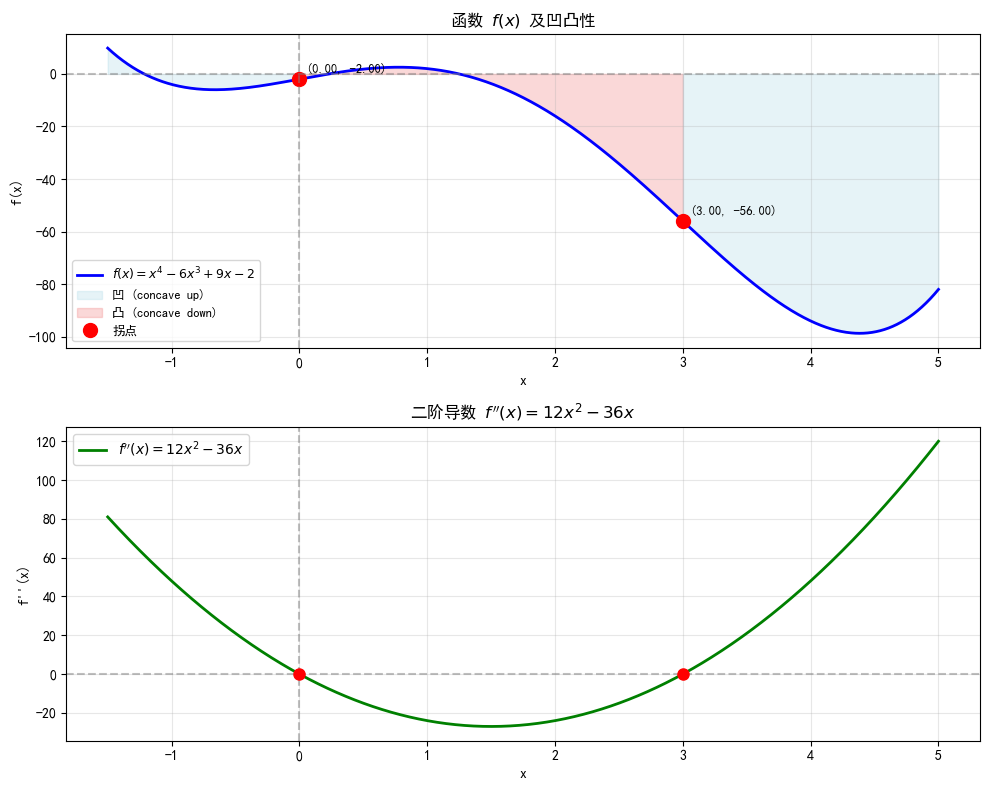


凹凸性总结
f(x) = x^4 - 6x^3 + 9x - 2
f'(x) = 4x^3 - 18x^2 + 9
f''(x) = 12*x*(x - 3)

拐点: x = 0.0000, 3.0000


In [26]:
# ========== f(x) = x^4 - 6x^3 + 9x - 2 的凹凸性分析 ==========
print("=" * 60)
print("f(x) = x^4 - 6x^3 + 9x - 2 的凹凸性分析")
print("=" * 60)

x = sp.symbols('x')

# 定义函数
f = x**4 - 6*x**3 + 9*x - 2
print(f"f(x) = {f}")

# ========== 计算二阶导数 ==========
print("\n" + "=" * 60)
print("计算二阶导数")
print("=" * 60)

f_prime = sp.diff(f, x)
f_double = sp.diff(f, x, 2)
print(f"f'(x) = {f_prime}")
print(f"f''(x) = {f_double}")

# 化简
f_double_simplified = sp.simplify(f_double)
print(f"f''(x) 化简 = {f_double_simplified}")

# ========== 求拐点（f''(x) = 0）==========
print("\n" + "=" * 60)
print("求拐点（f''(x) = 0）")
print("=" * 60)

# 用 nroots 求数值根
inflection_points_sym = sp.nroots(f_double)
inflection_points = [float(ip) for ip in inflection_points_sym if abs(ip.as_real_imag()[1]) < 1e-10]
inflection_points.sort()

print(f"拐点横坐标（数值）:")
for ip in inflection_points:
    print(f"  x = {ip:.6f}")

# 计算拐点的纵坐标
print(f"\n拐点坐标:")
for ip in inflection_points:
    y_val = float(f.subs(x, ip))
    print(f"  ({ip:.6f}, {y_val:.6f})")

# ========== 分析凹凸性 ==========
print("\n" + "=" * 60)
print("凹凸性分析")
print("=" * 60)

# 在各区间测试二阶导数的符号
print("\n各区间 f''(x) 符号:")
test_intervals = []
if len(inflection_points) > 0:
    test_intervals.append((-np.inf, inflection_points[0]))
    for i in range(len(inflection_points) - 1):
        test_intervals.append((inflection_points[i], inflection_points[i+1]))
    test_intervals.append((inflection_points[-1], np.inf))

for interval in test_intervals:
    left, right = interval
    if left == -np.inf:
        test_point = inflection_points[0] - 1
        interval_str = f"(-∞, {inflection_points[0]:.4f})"
    elif right == np.inf:
        test_point = inflection_points[-1] + 1
        interval_str = f"({inflection_points[-1]:.4f}, +∞)"
    else:
        test_point = (left + right) / 2
        interval_str = f"({left:.4f}, {right:.4f})"
    
    sign_val = f_double.subs(x, test_point)
    if sign_val > 0:
        sign_str = "正（+）"
        concavity = "凹（concave up）∪"
    elif sign_val < 0:
        sign_str = "负（-）"
        concavity = "凸（concave down）∩"
    else:
        sign_str = "零"
        concavity = "拐点"
    
    print(f"  {interval_str}: f''(x) {sign_str}, {concavity}")

# ========== 绘制图像 ==========
print("\n正在绘制图像...")

f_func = sp.lambdify(x, f, 'numpy')
f_double_func = sp.lambdify(x, f_double, 'numpy')

x_vals = np.linspace(-1.5, 5, 1000)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# 子图1：原函数 + 凹凸性标注
ax1.plot(x_vals, f_func(x_vals), 'b-', linewidth=2, label='$f(x) = x^4 - 6x^3 + 9x - 2$')

# 用不同颜色标注凹凸区间
for i, interval in enumerate(test_intervals):
    left, right = interval
    if left == -np.inf:
        x_seg = np.linspace(-1.5, right, 500)
    elif right == np.inf:
        x_seg = np.linspace(left, 5, 500)
    else:
        x_seg = np.linspace(left, right, 500)
    
    # 测试凹凸性
    test_pt = (x_seg[0] + x_seg[-1]) / 2
    is_concave_up = f_double.subs(x, test_pt) > 0
    
    color = 'lightblue' if is_concave_up else 'lightcoral'
    label_text = '凹 (concave up)' if is_concave_up else '凸 (concave down)'
    
    # 只标注一次
    if i == 0 or (i > 0 and label_text not in [l.get_label() for l in ax1.get_children() if hasattr(l, 'get_label')]):
        ax1.fill_between(x_seg, f_func(x_seg), alpha=0.3, color=color, label=label_text)
    else:
        ax1.fill_between(x_seg, f_func(x_seg), alpha=0.3, color=color)

# 标记拐点
for ip in inflection_points:
    y_val = float(f.subs(x, ip))
    ax1.plot(ip, y_val, 'ro', markersize=10, label='拐点' if ip == inflection_points[0] else '')
    ax1.annotate(f'({ip:.2f}, {y_val:.2f})', 
                xy=(ip, y_val), xytext=(5, 5), 
                textcoords='offset points', fontsize=9)

ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax1.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax1.grid(True, alpha=0.3)
ax1.set_xlabel('x')
ax1.set_ylabel('f(x)')
ax1.set_title('函数 $f(x)$ 及凹凸性')
ax1.legend(fontsize=9)

# 子图2：二阶导数
ax2.plot(x_vals, f_double_func(x_vals), 'g-', linewidth=2, label="$f''(x) = 12x^2 - 36x$")
ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax2.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
# 标记二阶导数的零点（拐点）
for ip in inflection_points:
    ax2.plot(ip, 0, 'ro', markersize=8)
ax2.grid(True, alpha=0.3)
ax2.set_xlabel('x')
ax2.set_ylabel("f''(x)")
ax2.set_title("二阶导数 $f''(x) = 12x^2 - 36x$")
ax2.legend()

plt.tight_layout()
plt.show()

# ========== 总结 ==========
print("\n" + "=" * 60)
print("凹凸性总结")
print("=" * 60)
print(f"f(x) = x^4 - 6x^3 + 9x - 2")
print(f"f'(x) = 4x^3 - 18x^2 + 9")
print(f"f''(x) = {f_double_simplified}")
print(f"\n拐点: x = {', '.join([f'{ip:.4f}' for ip in inflection_points])}")

极值分析:
  x=-0.6603, f=-6.0253, 局部极小值
  x=0.7774, f=2.5429, 局部极大值
  x=4.3829, f=-98.7051, 局部极小值


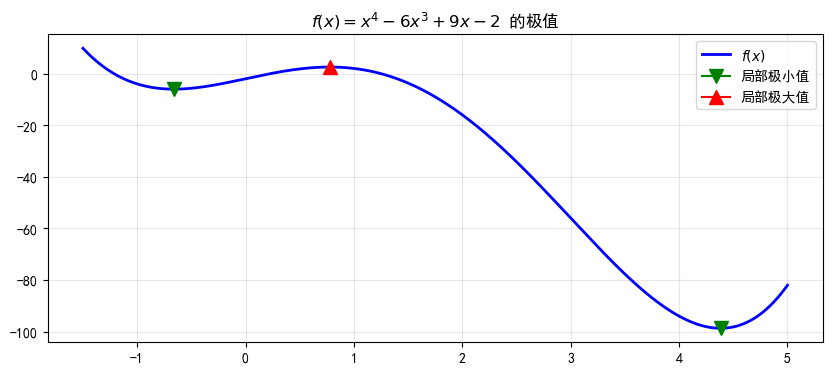

In [31]:
# 定义函数
def f(x): return x**4 - 6*x**3 + 9*x - 2
def f_prime(x): return 4*x**3 - 18*x**2 + 9

# 求驻点（f'(x)=0）
critical_points = []
for x0 in [-2, 0, 1, 4]:
    sol = root(f_prime, x0)
    if sol.success:
        cp = float(sol.x[0])
        if not any(abs(cp - e) < 1e-6 for e in critical_points):
            critical_points.append(cp)
critical_points.sort()

# 判断极值
print("极值分析:")
extrema = []
for cp in critical_points:
    f_val = f(cp)
    f2_val = 12*cp**2 - 36*cp  # f''
    if f2_val > 0:
        ext_type = "局部极小值"
    elif f2_val < 0:
        ext_type = "局部极大值"
    else:
        ext_type = "非极值"
    extrema.append((ext_type, cp, f_val))
    print(f"  x={cp:.4f}, f={f_val:.4f}, {ext_type}")

# 绘图
x_vals = np.linspace(-1.5, 5, 1000)
plt.figure(figsize=(10, 4))
plt.plot(x_vals, f(x_vals), 'b-', linewidth=2, label='$f(x)$')

# 修复：分别绘制极大值和极小值，确保图例正确
max_added = False
min_added = False

for ext_type, cp, f_val in extrema:
    if '极大' in ext_type:
        label = '局部极大值' if not max_added else ''
        plt.plot(cp, f_val, marker='^', color='red', markersize=10, label=label)
        max_added = True
    elif '极小' in ext_type:
        label = '局部极小值' if not min_added else ''
        plt.plot(cp, f_val, marker='v', color='green', markersize=10, label=label)
        min_added = True

plt.grid(True, alpha=0.3)
plt.legend()
plt.title('$f(x) = x^4 - 6x^3 + 9x - 2$ 的极值')
plt.show()

In [32]:
x = sp.symbols('x')
result = sp.integrate(1/sp.sin(x), x)
print(result)

log(cos(x) - 1)/2 - log(cos(x) + 1)/2


In [5]:
# 定义符号
x = sp.symbols('x')
y = sp.Function('y')

# 定义微分方程: y'''' - 2y''' + 5y'' = sin(x)
ode = sp.Eq(sp.diff(y(x), x, 4) - 2*sp.diff(y(x), x, 3) + 5*sp.diff(y(x), x, 2), sp.sin(x))

# 求解微分方程
solution = sp.dsolve(ode, y(x))
print("通解:")
print(solution)

通解:
Eq(y(x), C1 + C2*x + (C3*sin(2*x) + C4*cos(2*x))*exp(x) - sin(x)/5 - cos(x)/10)


不定积分结果:
exp(x)*sin(x)/2 + exp(x)*cos(x)/2

定积分 ∫_0^π e^x cos(x) dx:
-exp(pi)/2 - 1/2
数值近似: -12.070346


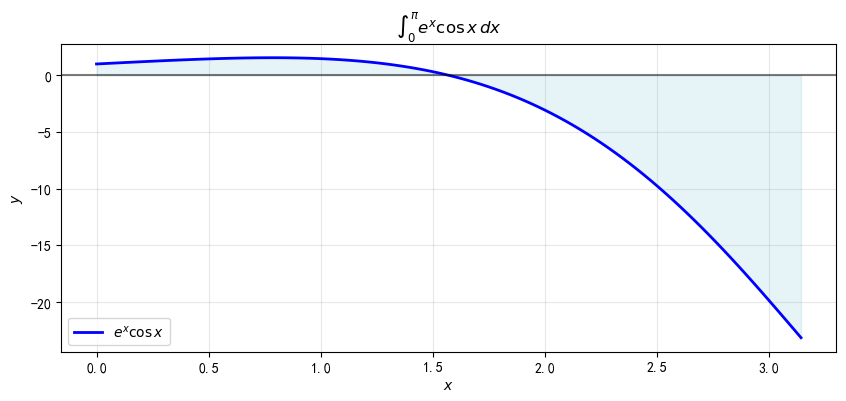

In [6]:
x = sp.symbols('x')

# 不定积分
indefinite = sp.integrate(sp.exp(x) * sp.cos(x), x)
print("不定积分结果:")
print(indefinite)  # 输出: exp(x)*sin(x)/2 + exp(x)*cos(x)/2

# 定积分（示例：从 0 到 π）
definite = sp.integrate(sp.exp(x) * sp.cos(x), (x, 0, sp.pi))
print("\n定积分 ∫_0^π e^x cos(x) dx:")
print(definite)  # 输出: -1/2 - exp(pi)/2
print(f"数值近似: {float(definite):.6f}")

# 可视化
import matplotlib.pyplot as plt
x_vals = np.linspace(0, np.pi, 100)
y_vals = np.exp(x_vals) * np.cos(x_vals)

plt.figure(figsize=(10, 4))
plt.plot(x_vals, y_vals, 'b-', linewidth=2, label='$e^x \cos x$')
plt.fill_between(x_vals, 0, y_vals, alpha=0.3, color='lightblue')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', linestyle='-', alpha=0.5)
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.title('$\int_0^\pi e^x \cos x \, dx$')
plt.legend()
plt.show()

不定积分结果:
Si(x)

定积分 ∫_0^∞ sin(x)/x dx:
pi/2
数值近似: 1.570796


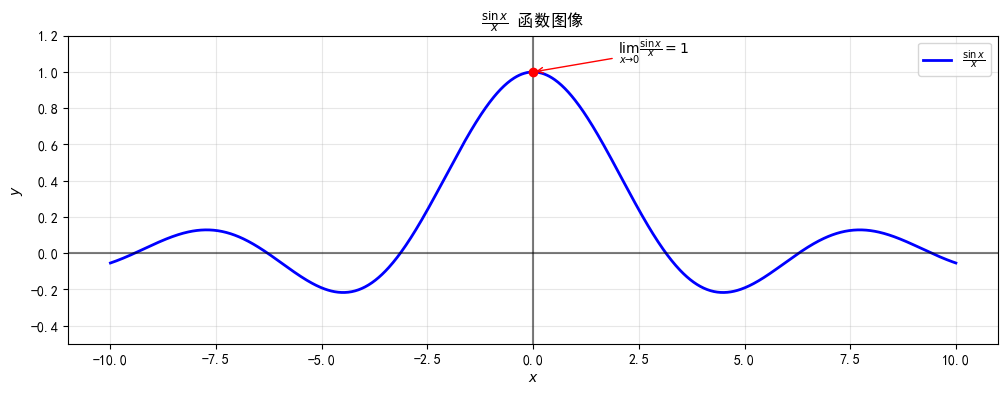

In [7]:
x = sp.symbols('x')

# 尝试不定积分 - Sympy 会用 Si(x) 表示
indefinite = sp.integrate(sp.sin(x) / x, x)
print("不定积分结果:")
print(indefinite)  # 输出: Si(x)

# 定积分 ∫_0^∞ sin(x)/x dx
definite = sp.integrate(sp.sin(x) / x, (x, 0, sp.oo))
print("\n定积分 ∫_0^∞ sin(x)/x dx:")
print(definite)  # 输出: pi/2

# 数值验证
print(f"数值近似: {float(definite):.6f}")  # 输出: 1.570796 (= π/2)

# 可视化 sin(x)/x 函数
x_vals = np.linspace(-10, 10, 1000)
x_vals = x_vals[x_vals != 0]  # 去掉 x=0 的点
y_vals = np.sin(x_vals) / x_vals

plt.figure(figsize=(12, 4))
plt.plot(x_vals, y_vals, 'b-', linewidth=2, label='$\\frac{\sin x}{x}$')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', linestyle='-', alpha=0.5)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.5)
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.title('$\\frac{\sin x}{x}$ 函数图像')
plt.ylim(-0.5, 1.2)

# 标记 x=0 处的极限值
plt.scatter([0], [1], color='red', zorder=5)
plt.annotate('$\\lim_{x \\to 0} \\frac{\sin x}{x} = 1$', 
             xy=(0, 1), xytext=(2, 1.1),
             arrowprops=dict(arrowstyle='->', color='red'))

plt.legend()
plt.show()

二重积分: ∬_D xy² dA  (先对 x 积分)


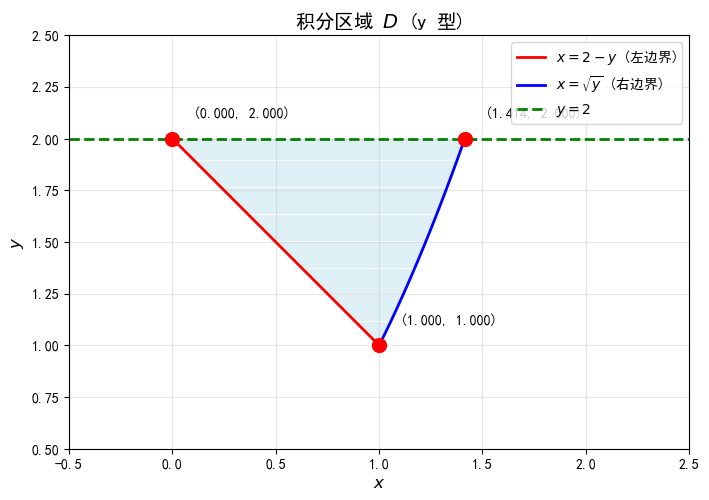


【积分区域】
  D = {(x, y) | 1 ≤ y ≤ 2, 2 - y ≤ x ≤ √y}

【计算步骤】
  ∬_D xy² dA = ∫_{y=1}^{2} ∫_{x=2-y}^{√y} xy² dx dy

  第一步：对 x 积分
    ∫_{2-y}^{√y} xy² dx = y**2*(y - (y - 2)**2)/2

  第二步：对 y 积分
    ∫₁² y**2*(y - (y - 2)**2)/2 dy = 193/120

【精确解】
  ∬_D xy² dA = 193/120
  ≈ 1.6083333333


In [9]:
# 定义符号
x, y = sp.symbols('x y', real=True)

# ==================== 可视化积分区域 ====================
print("=" * 60)
print("二重积分: ∬_D xy² dA  (先对 x 积分)")
print("=" * 60)

fig, ax = plt.subplots(figsize=(8, 6))

# 绘制边界曲线
y_plot = np.linspace(1, 2, 100)

# 左边界: x = 2 - y
x_left = 2 - y_plot
ax.plot(x_left, y_plot, 'r-', linewidth=2, label='$x = 2 - y$ (左边界)')

# 右边界: x = √y
x_right = np.sqrt(y_plot)
ax.plot(x_right, y_plot, 'b-', linewidth=2, label='$x = \sqrt{y}$ (右边界)')

# 上边界: y = 2
ax.axhline(y=2, color='g', linewidth=2, linestyle='--', label='$y = 2$')

# 填充区域 D
y_fill = np.linspace(1, 2, 200)
for y_val in y_fill:
    x_l = 2 - y_val
    x_r = np.sqrt(y_val)
    ax.fill_betweenx([y_val], x_l, x_r, alpha=0.3, color='lightblue')

# 标记交点
intersections = [(1, 1), (0, 2), (np.sqrt(2), 2)]
for ix, iy in intersections:
    ax.scatter([ix], [iy], color='red', s=100, zorder=5)
    ax.annotate(f'({ix:.3f}, {iy:.3f})', xy=(ix, iy), 
                xytext=(ix+0.1, iy+0.1), fontsize=10)

ax.set_xlabel('$x$', fontsize=12)
ax.set_ylabel('$y$', fontsize=12)
ax.set_title('积分区域 $D$ (y 型)', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10, loc='upper right')
ax.set_xlim(-0.5, 2.5)
ax.set_ylim(0.5, 2.5)
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

# ==================== 计算二重积分 ====================
print("\n【积分区域】")
print("  D = {(x, y) | 1 ≤ y ≤ 2, 2 - y ≤ x ≤ √y}")
print("\n【计算步骤】")
print("  ∬_D xy² dA = ∫_{y=1}^{2} ∫_{x=2-y}^{√y} xy² dx dy")

# 先对 x 积分
print("\n  第一步：对 x 积分")
inner_integral = sp.integrate(x * y**2, (x, 2 - y, sp.sqrt(y)))
print("    ∫_{2-y}^{√y} xy² dx = " + str(sp.simplify(inner_integral)))
# 再对 y 积分
print("\n  第二步：对 y 积分")
outer_integral = sp.integrate(inner_integral, (y, 1, 2))
print(f"    ∫₁² {sp.simplify(inner_integral)} dy = {outer_integral}")

# 数值近似
print(f"\n【精确解】")
print(f"  ∬_D xy² dA = {outer_integral}")
print(f"  ≈ {float(outer_integral):.10f}")

In [18]:
r, theta = sp.symbols('r theta', real=True)

# ==================== 极坐标计算 ====================
print("=" * 50)
print("二重积分: ∬_D e^(-(x²+y²)) dA (极坐标)")
print("=" * 50)

# 先对 r 积分
inner = sp.integrate(sp.exp(-r**2) * r, (r, 0, 1))
print("\n∫_0^1 e^(-r²) r dr = " + str(inner))
print("= " + str(sp.simplify(inner)))

# 再对 θ 积分
outer = sp.integrate(inner, (theta, 0, 2*sp.pi))
print("\n∫_0^(2π) " + str(inner) + " dθ = " + str(outer))

# 最终结果
print("\n【最终结果】")
print("  ∬_D e^(-(x²+y²)) dA = π(1 - 1/e)")
print("  = " + str(outer))
print("  ≈ " + str(float(outer)))

二重积分: ∬_D e^(-(x²+y²)) dA (极坐标)

∫_0^1 e^(-r²) r dr = 1/2 - exp(-1)/2
= -(1 - E)*exp(-1)/2

∫_0^(2π) 1/2 - exp(-1)/2 dθ = 2*pi*(1/2 - exp(-1)/2)

【最终结果】
  ∬_D e^(-(x²+y²)) dA = π(1 - 1/e)
  = 2*pi*(1/2 - exp(-1)/2)
  ≈ 1.9858653037988716


h(x1, x2) = 5x1 + 7x2
x1 ∈ [0, 9], x2 ∈ [4, 13]

【网格点 y 值矩阵】
[[ 28.  33.  38.  43.  48.  53.  58.  63.  68.  73.]
 [ 35.  40.  45.  50.  55.  60.  65.  70.  75.  80.]
 [ 42.  47.  52.  57.  62.  67.  72.  77.  82.  87.]
 [ 49.  54.  59.  64.  69.  74.  79.  84.  89.  94.]
 [ 56.  61.  66.  71.  76.  81.  86.  91.  96. 101.]
 [ 63.  68.  73.  78.  83.  88.  93.  98. 103. 108.]
 [ 70.  75.  80.  85.  90.  95. 100. 105. 110. 115.]
 [ 77.  82.  87.  92.  97. 102. 107. 112. 117. 122.]
 [ 84.  89.  94.  99. 104. 109. 114. 119. 124. 129.]
 [ 91.  96. 101. 106. 111. 116. 121. 126. 131. 136.]]


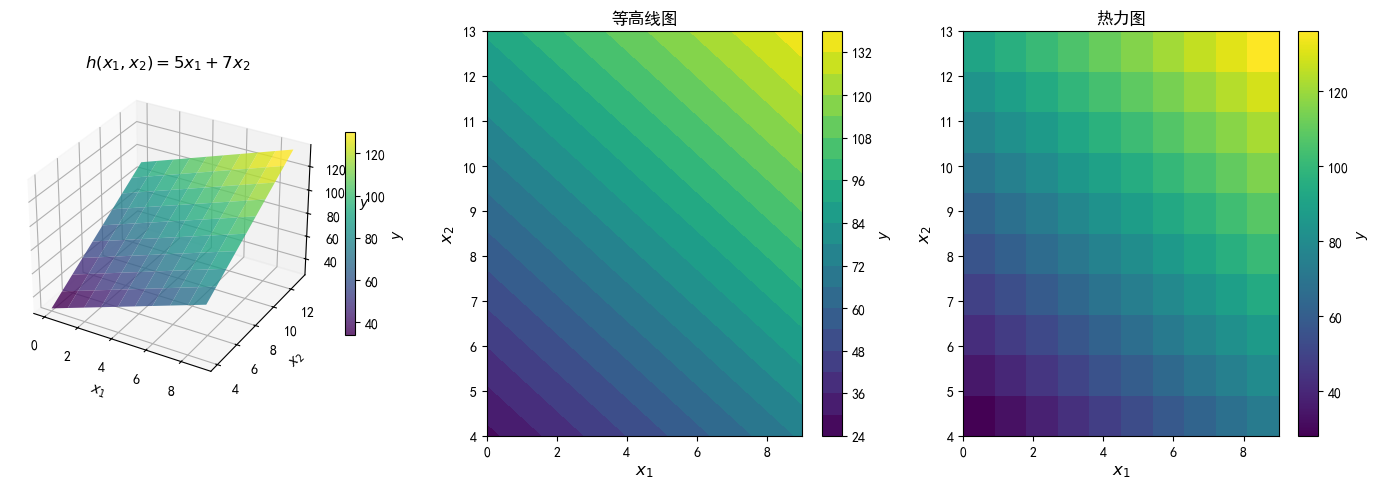


【极值分析】
  最小 y 值: 28.00  (x1=0, x2=4)
  最大 y 值: 136.00  (x1=9, x2=13)

  由于 h 是线性函数，极值出现在顶点:
    最小: x1=0,  x2=4   → y = 28
    最大: x1=9,  x2=13  → y = 136


In [23]:
# ==================== 方法1：网格点 (用于可视化) ====================
print("=" * 60)
print("h(x1, x2) = 5x1 + 7x2")
print("x1 ∈ [0, 9], x2 ∈ [4, 13]")
print("=" * 60)

# 创建网格
x1_vals = np.linspace(0, 9, 10)   # x1: 0 到 9，取 10 个点
x2_vals = np.linspace(4, 13, 10)  # x2: 4 到 13，取 10 个点
X1, X2 = np.meshgrid(x1_vals, x2_vals)

# 计算 y 值
Y = 5 * X1 + 7 * X2

print("\n【网格点 y 值矩阵】")
print(Y)

# ==================== 可视化 ====================
# 图1：3D 曲面
fig = plt.figure(figsize=(14, 5))

ax1 = fig.add_subplot(131, projection='3d')
surf = ax1.plot_surface(X1, X2, Y, cmap='viridis', alpha=0.8)
ax1.set_xlabel('$x_1$')
ax1.set_ylabel('$x_2$')
ax1.set_zlabel('$y$')
ax1.set_title('$h(x_1, x_2) = 5x_1 + 7x_2$', fontsize=12)
fig.colorbar(surf, ax=ax1, shrink=0.5, label='$y$')

# 图2：等高线图
ax2 = fig.add_subplot(132)
contour = ax2.contourf(X1, X2, Y, levels=20, cmap='viridis')
ax2.set_xlabel('$x_1$', fontsize=12)
ax2.set_ylabel('$x_2$', fontsize=12)
ax2.set_title('等高线图', fontsize=12)
fig.colorbar(contour, ax=ax2, label='$y$')

# 图3：颜色映射热力图
ax3 = fig.add_subplot(133)
im = ax3.imshow(Y, cmap='viridis', aspect='auto', 
                origin='lower',
                extent=[0, 9, 4, 13])
ax3.set_xlabel('$x_1$', fontsize=12)
ax3.set_ylabel('$x_2$', fontsize=12)
ax3.set_title('热力图', fontsize=12)
fig.colorbar(im, ax=ax3, label='$y$')

plt.tight_layout()
plt.show()

# ==================== 极值分析 ====================
print("\n【极值分析】")

# 修复：使用 np.unravel_index 获取二维索引
min_idx = np.unravel_index(np.argmin(Y), Y.shape)
max_idx = np.unravel_index(np.argmax(Y), Y.shape)

print("  最小 y 值: {:.2f}  (x1={:.0f}, x2={:.0f})".format(
    Y[min_idx], X1[min_idx], X2[min_idx]))
print("  最大 y 值: {:.2f}  (x1={:.0f}, x2={:.0f})".format(
    Y[max_idx], X1[max_idx], X2[max_idx]))

print("\n  由于 h 是线性函数，极值出现在顶点:")
print("    最小: x1=0,  x2=4   → y = {}".format(5*0 + 7*4))
print("    最大: x1=9,  x2=13  → y = {}".format(5*9 + 7*13))

梯度下降拟合 h(x) = 5x1 + 7x2

真实参数: w1=5, w2=7
样本数: 100
x1 范围: [0.05, 8.88]
x2 范围: [4.06, 12.87]

初始参数: w1=-0.0680, w2=0.0232
  Epoch  200: loss=0.044147, w1=4.9311, w2=7.0343
  Epoch  400: loss=0.000129, w1=4.9963, w2=7.0019
  Epoch  600: loss=0.000000, w1=4.9998, w2=7.0001
  Epoch  800: loss=0.000000, w1=5.0000, w2=7.0000
  Epoch 1000: loss=0.000000, w1=5.0000, w2=7.0000
  Epoch 1200: loss=0.000000, w1=5.0000, w2=7.0000
  Epoch 1400: loss=0.000000, w1=5.0000, w2=7.0000
  Epoch 1600: loss=0.000000, w1=5.0000, w2=7.0000
  Epoch 1800: loss=0.000000, w1=5.0000, w2=7.0000
  Epoch 2000: loss=0.000000, w1=5.0000, w2=7.0000

最终参数: w1=5.0000, w2=7.0000
真实参数: w1=5, w2=7
误差: Δw1=0.0000, Δw2=0.0000


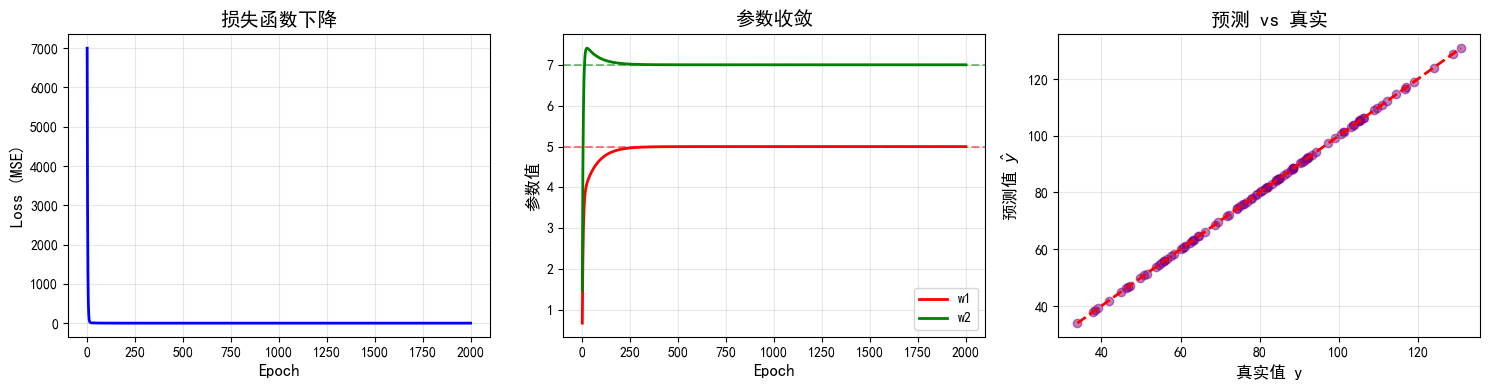

In [8]:
# ==================== 1. 数据生成 ====================
np.random.seed(42)
n_samples = 100

# 均匀采样
x1 = np.random.uniform(0, 9, n_samples)    # x1 ∈ [0, 9]
x2 = np.random.uniform(4, 13, n_samples)   # x2 ∈ [4, 13]

# 真实函数：y = 5*x1 + 7*x2
true_w1, true_w2 = 5, 7
y = true_w1 * x1 + true_w2 * x2

print("=" * 60)
print("梯度下降拟合 h(x) = 5x1 + 7x2")
print("=" * 60)
print(f"\n真实参数: w1={true_w1}, w2={true_w2}")
print(f"样本数: {n_samples}")
print(f"x1 范围: [{x1.min():.2f}, {x1.max():.2f}]")
print(f"x2 范围: [{x2.min():.2f}, {x2.max():.2f}]")

# ==================== 2. 梯度下降 ====================
# 初始化参数（随机初始化）
w1 = np.random.randn() * 0.1
w2 = np.random.randn() * 0.1
print(f"\n初始参数: w1={w1:.4f}, w2={w2:.4f}")

learning_rate = 0.001
n_epochs = 2000

losses = []
w1_history = []
w2_history = []

for epoch in range(n_epochs):
    # 前向传播
    y_pred = w1 * x1 + w2 * x2
    
    # 计算损失
    loss = np.mean((y_pred - y) ** 2)
    
    # 反向传播（梯度）
    grad_w1 = 2 * np.mean((y_pred - y) * x1)
    grad_w2 = 2 * np.mean((y_pred - y) * x2)
    
    # 更新参数
    w1 -= learning_rate * grad_w1
    w2 -= learning_rate * grad_w2
    
    # 记录
    losses.append(loss)
    w1_history.append(w1)
    w2_history.append(w2)
    
    if (epoch + 1) % 200 == 0:
        print(f"  Epoch {epoch+1:4d}: loss={loss:.6f}, w1={w1:.4f}, w2={w2:.4f}")

print(f"\n最终参数: w1={w1:.4f}, w2={w2:.4f}")
print(f"真实参数: w1={true_w1}, w2={true_w2}")
print(f"误差: Δw1={abs(w1-true_w1):.4f}, Δw2={abs(w2-true_w2):.4f}")

# ==================== 3. 可视化 ====================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 图1：损失下降曲线
axes[0].plot(losses, 'b-', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss (MSE)', fontsize=12)
axes[0].set_title('损失函数下降', fontsize=14)
axes[0].grid(True, alpha=0.3)

# 图2：参数收敛过程
axes[1].plot(w1_history, 'r-', linewidth=2, label='w1')
axes[1].plot(w2_history, 'g-', linewidth=2, label='w2')
axes[1].axhline(y=true_w1, color='r', linestyle='--', alpha=0.5)
axes[1].axhline(y=true_w2, color='g', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('参数值', fontsize=12)
axes[1].set_title('参数收敛', fontsize=14)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# 图3：预测 vs 真实（散点图）
y_pred_final = w1 * x1 + w2 * x2
axes[2].scatter(y, y_pred_final, alpha=0.5, color='purple')
axes[2].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=2)
axes[2].set_xlabel('真实值 y', fontsize=12)
axes[2].set_ylabel('预测值 $\\hat{y}$', fontsize=12)
axes[2].set_title('预测 vs 真实', fontsize=14)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()